In [21]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,List,Sequence,Annotated

In [3]:
class EmployeeState(TypedDict):
    name:str
    salary:float
    age:int
    decision:Literal["std_hr","forced_hr"]
    result:str

In [4]:
def analyse_employee(state:EmployeeState)->EmployeeState:
    age=state['age']
    salary=state['salary']
    if age<=30 and salary<=40000:
        state['decision']="std_hr"
    else :
        state['decision']="forced_hr"
    print(f"le dossier de {state['name']} a ete analyse")    
    return state        

In [5]:
def standard_hr_process(state:EmployeeState):
    state['result']=f"le dossier de {state['name']} a ete traite de maniere standard"
    print("******************")
    print(state['result'])
    print("******************")
    return state

In [6]:
def forced_hr_process(state:EmployeeState):
    state['result']=f"le dossier de {state['name']} a ete traite de maniere forcee"
    print("#####################")
    print(state['result'])
    print("#####################")
    return state

In [7]:
def router(state:EmployeeState):
    return state['decision']

In [8]:
workflow=StateGraph(EmployeeState)
workflow.add_node("analyse_node",analyse_employee)
workflow.add_node("standard_hr_node",standard_hr_process)
workflow.add_node("forced_hr_node",forced_hr_process)
workflow.add_edge(START,"analyse_node")
workflow.add_conditional_edges(
    "analyse_node",router,{
        "std_hr":"standard_hr_node",
        "forced_hr":"forced_hr_node"
    })
workflow.add_edge("standard_hr_node",END)

workflow.add_edge("forced_hr_node",END)
graph=workflow.compile()

In [9]:
from IPython.display import Image

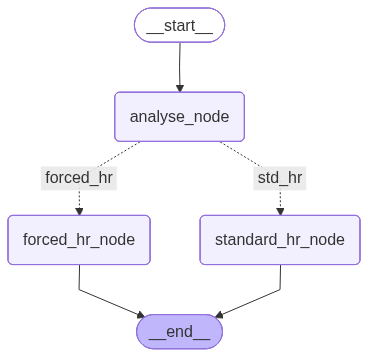

In [10]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
result=graph.invoke({
    "name":"Mohamed","age":24,"salary":20000
})

le dossier de Mohamed a ete analyse
******************
le dossier de Mohamed a ete traite de maniere standard
******************


In [12]:
print(result)

{'name': 'Mohamed', 'salary': 20000, 'age': 24, 'decision': 'std_hr', 'result': 'le dossier de Mohamed a ete traite de maniere standard'}


In [45]:
from langchain.tools import tool
from langchain.messages import SystemMessage,AIMessage,ToolMessage,HumanMessage
from langchain_core.messages import BaseMessage,AnyMessage
from langgraph.graph import add_messages
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from dotenv.ipython import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [37]:
load_dotenv(override=True)

True

In [17]:
@tool
def add(a:float,b:float):
    """  

    add 2 numbers a and b
    """
    print(f"add {a} to {b}")
    return a+b

In [18]:
@tool
def multiply(a:float,b:float):
    """  

    multiply 2 numbers a and b
    """
    print(f"multiply {a} to {b}")
    return a*b

In [19]:
@tool
def divide(a:float,b:float):
    """  

    divide 2 numbers a and b
    """
    print(f"divide {a} to {b}")
    return a/b

In [20]:
tools=[add,multiply,divide]

In [24]:
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]

In [38]:
llm=ChatOpenAI(model="gpt-4o",temperature=0)
llm_with_tools=llm.bind_tools(tools=tools)

In [39]:
def assistant(state:AgentState)->AgentState:
    response=llm_with_tools.invoke(state['messages'])
    print("*********")
    print("LLM INVOKED")
    return {"messages":[response]}

In [28]:
def should_continue(state:AgentState):
    last_message=state['messages'][-1]
    if not last_message.tool_calls:
        return "end"
    else :
        return "continue"

In [46]:
workflow=StateGraph(AgentState)
workflow.add_node("assistant",assistant)
workflow.add_node("tools",ToolNode(tools=tools))
workflow.set_entry_point("assistant")
workflow.add_conditional_edges(
    "assistant",
    should_continue,
    {
        "end":END,
        "continue":"tools"
    }
)
workflow.add_edge("tools","assistant")
memory=InMemorySaver()
graph=workflow.compile(checkpointer=memory)

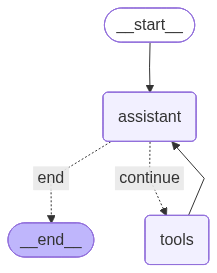

In [41]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
resp=graph.invoke({
    "messages":[
        HumanMessage("Ajoute 5 a 20 puis multiplie le resultat par 15 puis donne moi un proberbe en arabe")
    ]
})

*********
LLM INVOKED
add 5.0 to 20.0
multiply 25.0 to 15.0
*********
LLM INVOKED


In [44]:
print(resp['messages'][-1].content)

Le résultat de l'addition de 5 et 20 est 25, et en multipliant ce résultat par 15, on obtient 375.

Voici un proverbe en arabe : "الصبر مفتاح الفرج" qui signifie "La patience est la clé de la délivrance."


In [50]:
config={"configurable":{"thread_id":"1"}}
resp=graph.invoke({
    "messages":[
        HumanMessage("Mon nom c'est MOUSSA")
    ]
},config=config)
print(resp['messages'][-1].content)

*********
LLM INVOKED
Bonjour Moussa ! Comment puis-je vous aider aujourd'hui ?


In [51]:
config={"configurable":{"thread_id":"1"}}
resp=graph.invoke({
    "messages":[
        HumanMessage("Quel est mon nom")
    ]
},config=config)
print(resp['messages'][-1].content)

*********
LLM INVOKED
Votre nom est Moussa.
